In [15]:
from IPython.display import Image
import h5py
from matplotlib import pyplot as plt
import numpy as np
import os

In [16]:
#os.listdir('/')
path = "/Volumes/Crucial X9/qdev/data/2L-4S-HCN-04112025/"

$$ C_g = \frac{e}{\Delta V_g} $$

$$ C_g = \epsilon_r \epsilon_0 \frac A d $$


$A$ = island area
$d$ = hBN thickness
$V_g$ = distance between N & N+1 occupation

$$E_c = \frac{e^2}{2C_\Sigma} =  \frac{e\Delta V_{sd}}{2} = {[C][V] = J}$$
$$E_c(eV) = \frac{e}{2C_\Sigma} =  \frac{\Delta V_{sd}}{2} = {[C][V]/e[C] = eV}$$
$$\alpha = \frac{C_g}{C_\Sigma}$$


In [17]:
def SET_Cg(V_g):
    e = 1.602e-19
    return e/V_g

def SET_island_area(d, V_g):
    eps_0 = 8.85e-12
    eps_r = 3.4
    area = SET_Cg(V_g) * d / eps_0 / eps_r
    return np.round(area * 1e6 * 1e6,2)

def SET_Ec(V_sd):
    #e = 1.602e-19
    return V_sd/2

def SET_Ctot(V_sd):
    e = 1.602e-19
    return e/2/SET_Ec(V_sd)

def SET_alpha(V_g, V_sd):
    return np.round(SET_Cg(V_g) / SET_Ctot(V_sd), 2)

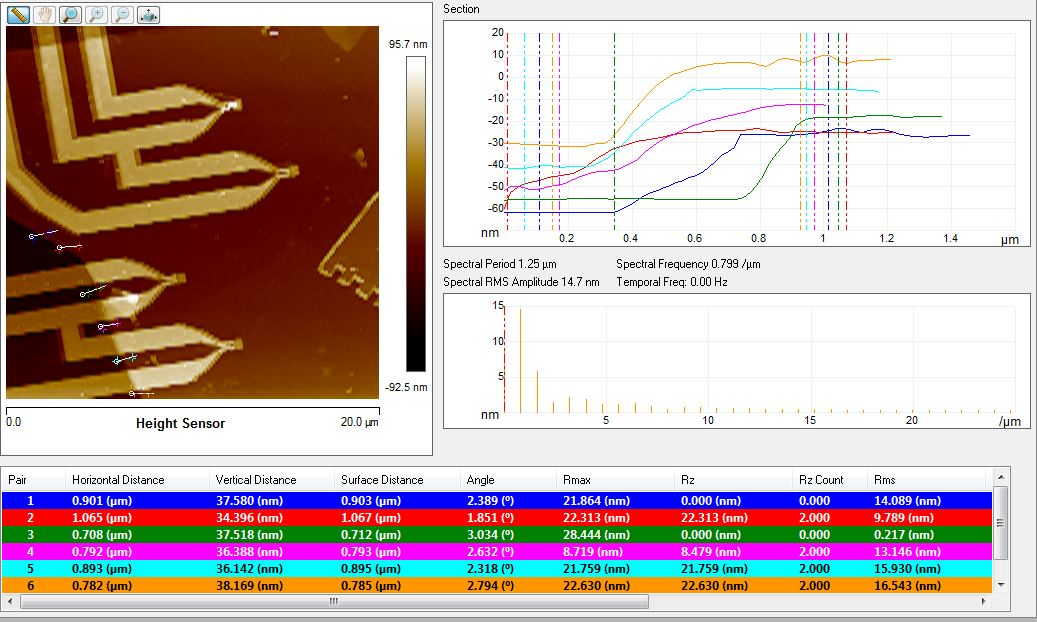

In [18]:
Image("bottom-left.jpg", width = 400)

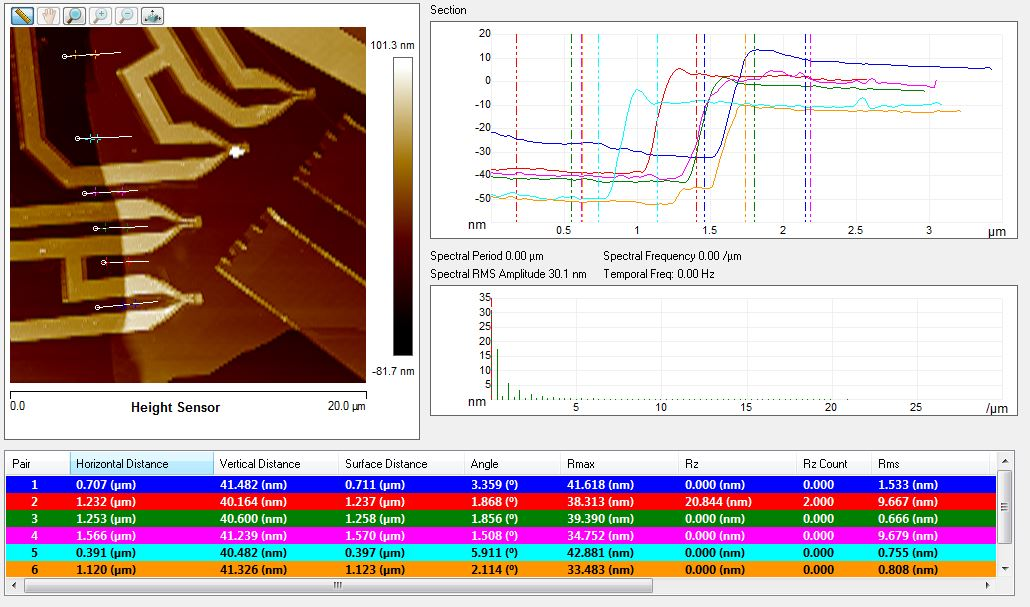

In [19]:
Image("bottom-right.jpg", width = 400)

In [20]:
def plot_h5_2d(
    filename,
    dataset_key,
    gradient_axis=0,
    ax=None,
    title=None,
    xlim=None,
    ylim=None,
    xlabel='X',
    ylabel='Y',
    clabel='Value',
    grid_x=None,
    grid_y=None,
    
    **imshow_kwargs
):
    """
    Plot a 2D dataset from an HDF5 file on a specified Matplotlib Axes,
    with optional cropping, axis labels, and colorbar label.

    Parameters
    ----------
    filename : str
        Path to the .h5 file.
    dataset_key : str
        Key for the 2D dataset (e.g., 'SET4_2d').
    gradient_axis : int or None
        If not None, compute gradient along this axis before plotting.
    ax : matplotlib.axes.Axes or None
        If given, draw on this axis. If None, create a new figure.
    title : str, optional
        Title for the plot.
    xlim : tuple of float, optional
        (x_min, x_max) range to crop in x-direction.
    ylim : tuple of float, optional
        (y_min, y_max) range to crop in y-direction.
    xlabel : str
        Label for the x-axis.
    ylabel : str
        Label for the y-axis.
    clabel : str
        Label for the colorbar.
    imshow_kwargs : dict
        Additional keyword arguments passed to `imshow`.

    Returns
    -------
    im : matplotlib.image.AxesImage
        The image object created by imshow.
    """
    import h5py
    import numpy as np
    import matplotlib.pyplot as plt

    with h5py.File(filename, 'r') as f:
        data = f[dataset_key][()]
        x = f['sweepgates_x'][()]
        y = f['sweepgates_y'][()]

        xvals = np.linspace(x[0][1], x[0][2], data.shape[1])
        yvals = np.linspace(y[0][1], y[0][2], data.shape[0])

        # Optional cropping
        if xlim is not None:
            x_mask = (xvals >= xlim[0]) & (xvals <= xlim[1])
            data = data[:, x_mask]
            xvals = xvals[x_mask]
        if ylim is not None:
            y_mask = (yvals >= ylim[0]) & (yvals <= ylim[1])
            data = data[y_mask, :]
            yvals = yvals[y_mask]

        extent = [xvals[0], xvals[-1], yvals[0], yvals[-1]]

        if gradient_axis is not None:
            data = np.gradient(data, axis=gradient_axis, edge_order = 2)

    if ax is None:
        fig, ax = plt.subplots()

    im = ax.imshow(data, extent=extent, origin='lower', aspect='auto', **imshow_kwargs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    if ax.figure == plt.gcf():
        plt.colorbar(im, ax=ax, label=clabel)

    if grid_x:
        ax.set_xticks(np.arange(xlim[0] if xlim else xvals[0], xlim[1] if xlim else xvals[-1], grid_x))
        
    if grid_y:
        ax.set_yticks(np.arange(ylim[0] if ylim else yvals[0], ylim[1] if ylim else ifyvals[-1], grid_y))

    if grid_x or grid_y:
        ax.grid(color='w', linestyle='--', linewidth=1)
    return im

In [21]:
#### can use subplots ###
# fig, ax = plt.subplots(1, 2)
# plot_h5_2d('dat31.h5', 'SET3_2d', gradient_axis=None, ax = ax[0])
# plot_h5_2d('dat31.h5', 'SET1_2d', gradient_axis=0, ax=ax[1])

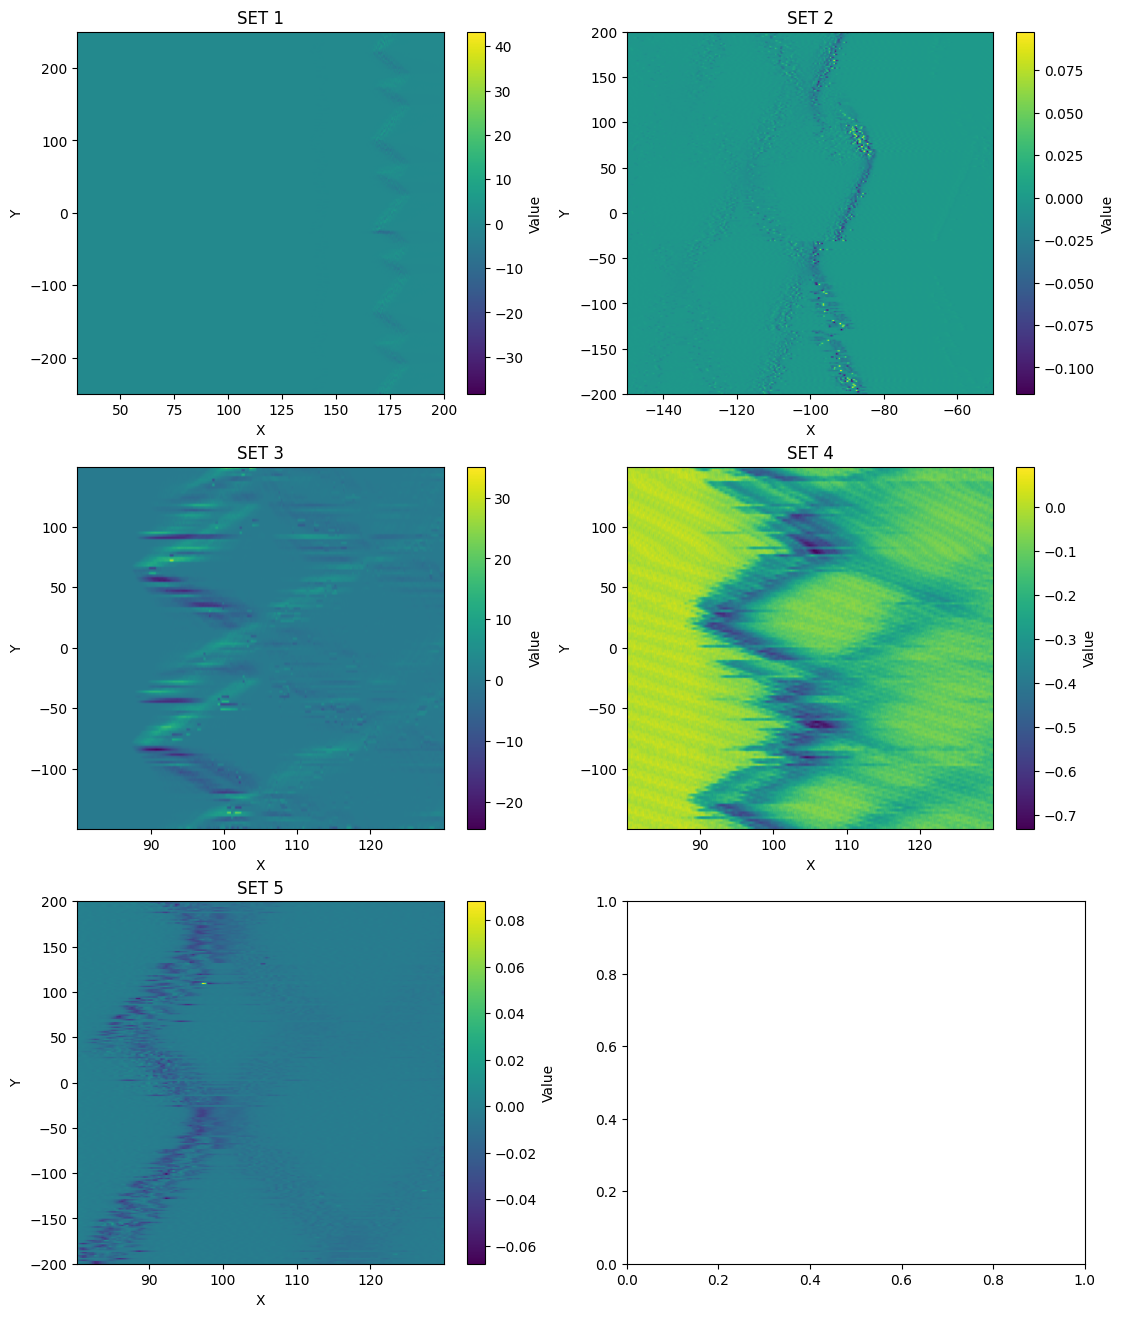

In [22]:
fig, ax = plt.subplots(3, 2, figsize=(13,16))

plot_h5_2d(path+'dat31.h5', 'SET1_2d', gradient_axis=0, ax = ax[0,0], title = "SET 1")
plot_h5_2d(path+'dat75.h5', 'SET2_2d', gradient_axis=1, ax = ax[0,1], title = "SET 2", xlim = (-150,-50))
plot_h5_2d(path+'dat31.h5', 'SET3_2d', gradient_axis=0, ax = ax[1,0], title = "SET 3", xlim = (80,130), ylim = (-150,150))
plot_h5_2d(path+'dat38.h5', 'SET4_2d', gradient_axis=1, ax = ax[1,1], title = "SET 4", xlim = (80,130), ylim = (-150,150))
plot_h5_2d(path+'dat75.h5', 'SET5_2d', gradient_axis=1, ax = ax[2,0], title = "SET 5", xlim = (80,130))

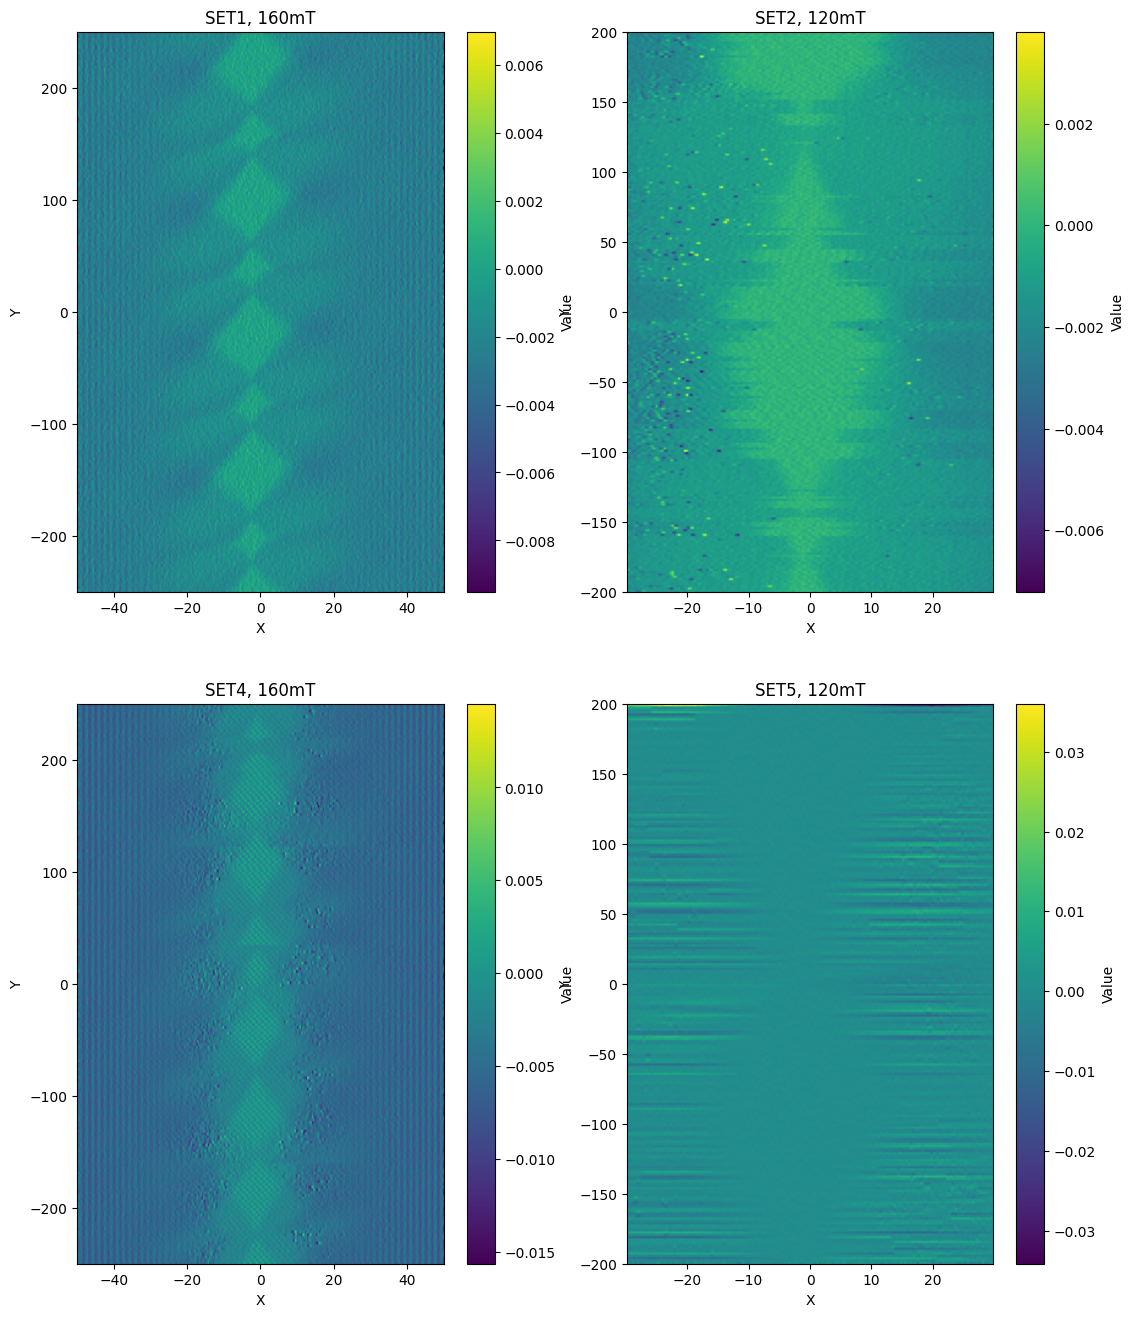

In [23]:
## finite field
fig, ax = plt.subplots(2, 2, figsize=(13,16))
plot_h5_2d(path+'dat80.h5', 'SET1_2d', gradient_axis=1, ax = ax[0,0], title = "SET1, 160mT")#, xlim = (-15,15), ylim = (-60,150), grid_x = 5, grid_y = 10)
plot_h5_2d(path+'dat80.h5', 'SET4_2d', gradient_axis=1, ax = ax[1,0], title = "SET4, 160mT")#, xlim = (-10,10))#, ylim = (-150,150))
plot_h5_2d(path+'dat78.h5', 'SET2_2d', gradient_axis=1, ax = ax[0,1], title = "SET2, 120mT", xlim = (-30,30))#, grid_x = 10)
plot_h5_2d(path+'dat78.h5', 'SET5_2d', gradient_axis=0, ax = ax[1,1], title = "SET5, 120mT", xlim = (-30,30))


In [24]:
#f = h5py.File(path + "dat79.h5", 'r')
#f.keys()

In [25]:
SET_island_area(37e-9, 75e-5), SET_island_area(37e-9, 300e-5),  SET_island_area(41e-9, 75e-5), SET_island_area(41e-9, 200e-5) 

(0.26, 0.07, 0.29, 0.11)

In [26]:
(SET_Ec(20e-5) * 1e6, SET_Ec(25e-5) * 1e6, SET_Ec(12e-5) * 1e6,SET_Ec(27e-5) * 1e6)

(100.0, 125.0, 60.0, 135.0)

In [27]:
SET_alpha(75e-5, 20e-5), SET_alpha(300e-5, 25e-5), SET_alpha(75e-5, 12e-5), SET_alpha(200e-5, 27e-5)

(0.27, 0.08, 0.16, 0.13)

In [28]:
## fridge
kb = 8.6e-5 #eV/K
T = 500e-3 #K
kb * T * 1e6

43.0